### GPT가 알려준 LSTM 쓰는법

In [ ]:
import pandas as pd
# path = '/content/drive/MyDrive/영화/'
# df = pd.read_pickle(path+'movie_reviews.pkl')
# df = df.dropna(subset=['별점'])
# df = df[df['별점']!='첫 번째 감상평을 등록 하세요!']
# df['별점'] = df['별점'].astype('int')

dataset = df[(df['별점']==9)|(df['별점']<=5)][['clean_review', '별점']]

In [ ]:
dataset['별점'].mean()  #긍정리뷰가 훨씬 많음

5.990841092962906

In [ ]:
dataset['labels'] = dataset['별점'].replace({8:1,9:1,10:1,5:0,4:0,1:0,2:0,3:0})

In [ ]:
dataset.groupby(['labels']).count()

,clean_review,별점
labels,,
0,7324,7324
1,5778,5778


In [ ]:
# 8이상 긍정 1 , 3 이하 부정 0
reviews = list(dataset['clean_review'])  # 영화 리뷰를 저장할 리스트
labels = list(dataset['labels'])   # 리뷰의 감성(긍정 또는 부정)을 저장할 리스트
len(reviews), len(labels)

(13102, 13102)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dense

# 감성 라벨을 이진 분류로 변환
labels = np.array(labels)

# 리뷰를 정수 시퀀스로 변환
vocab_size = 10000  # 사용할 단어의 최대 개수
max_len = 200  # 리뷰의 최대 길이
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=vocab_size)
tokenizer.fit_on_texts(reviews)
sequences = tokenizer.texts_to_sequences(reviews)
X_data = pad_sequences(sequences, maxlen=max_len)

# LSTM 모델 구축
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len))
model.add(LSTM(units=64))
model.add(Dense(units=1, activation='sigmoid'))

# 모델 컴파일
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 모델 학습
model.fit(X_data, labels, batch_size=64, epochs=10, validation_split=0.2)

# 모델 평가는 생략합니다. 필요하다면 추가하셔야 합니다.


Epoch 1/10
164/164 [==============================] - 18s 88ms/step - loss: 0.5666 - accuracy: 0.6999 - val_loss: 0.4608 - val_accuracy: 0.7848
Epoch 2/10
164/164 [==============================] - 8s 48ms/step - loss: 0.3049 - accuracy: 0.8713 - val_loss: 0.4856 - val_accuracy: 0.7841
Epoch 3/10
164/164 [==============================] - 4s 25ms/step - loss: 0.1963 - accuracy: 0.9205 - val_loss: 0.6375 - val_accuracy: 0.7627
Epoch 4/10
164/164 [==============================] - 4s 23ms/step - loss: 0.1404 - accuracy: 0.9456 - val_loss: 0.6870 - val_accuracy: 0.7661
Epoch 5/10
164/164 [==============================] - 3s 21ms/step - loss: 0.1100 - accuracy: 0.9571 - val_loss: 0.7873 - val_accuracy: 0.7650
Epoch 6/10
164/164 [==============================] - 3s 21ms/step - loss: 0.0921 - accuracy: 0.9620 - val_loss: 0.8582 - val_accuracy: 0.7581
Epoch 7/10
164/164 [==============================] - 2s 14ms/step - loss: 0.0780 - accuracy: 0.9684 - val_loss: 0.9814 - val_accuracy: 0.755

In [ ]:
def review_to_input(review):
  vocab_size = 10000  # 사용할 단어의 최대 개수
  max_len = 200  # 리뷰의 최대 길이
  tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=vocab_size)
  tokenizer.fit_on_texts(review)
  sequences = tokenizer.texts_to_sequences(review)
  X_data = pad_sequences(sequences, maxlen=max_len)
  return X_data

In [ ]:
sample = df[(df['별점']==1)][['clean_review', '별점']].head(2)
list(sample['clean_review'])

['1990년대에만들어진것같은영화', '왜곡까지 해야했음   그건아니지   ']

In [ ]:
review = ['초반까지는 재밌었는데 뒤로갈수록 지루하네요.'
         , '임시완은 이제 전문 배우라고 말해도 손색이 없을 정도로 연기를 잘한다 좀 더 탄탄한 영화를 만나서 제대로 대박 터트렸으면 좋겠다는 생각이 든다.'
         , '재미있게 봤지만 실제 사실과는 다른 부분이 매우 불편하다.미국이 자금을 도와준것과(대국민모금X), 태국기 달기위해 기자회견하는건 역사 왜곡이라고 생각될 정도;;;보면서 묘하게 미국을 싫어하는것 같은 느낌이 들던데 이런식으로 왜곡한다면 일본이랑 다를바가 무엇인가?'
         , '마지막 마라톤 장면 진짜 잘찍음'
         , '주제 자체가 신파라 그럭저럭 감동 받으며 봤지만왜곡 수준이 참,,, 다들 왜곡논란 한 번 찾아보세요.']
X_data = review_to_input(review)

In [ ]:
# 예측 수행
predictions = model.predict(X_data)

# 예측된 확률값을 기반으로 클래스를 확인
threshold = 0.5  # 임계값 설정
predicted_labels = [1 if pred > threshold else 0 for pred in predictions]

# 예측된 클래스 출력
print(predictions, predicted_labels)

1/1 [==============================] - 0s 377ms/step
[[9.9128358e-02]
 [6.5868424e-04]
 [9.2822480e-01]
 [1.1955401e-01]
 [3.1135466e-02]] [0, 0, 1, 0, 0]


In [ ]:
review = ['왜곡까지 해야했음   그건아니지   ']
X_data = review_to_input(review)

In [ ]:
# 예측 수행
predictions = model.predict(X_data)

# 예측된 확률값을 기반으로 클래스를 확인
threshold = 0.5  # 임계값 설정
predicted_labels = [1 if pred > threshold else 0 for pred in predictions]

# 예측된 클래스 출력
print(predictions, predicted_labels)  # 0 : 부정리뷰 예측

1/1 [==============================] - 0s 19ms/step
[[0.05409879]] [0]


### 데이터 전처리, train test 분리

In [2]:
!pip install konlpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 20.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 488.6/488.6 kB 9.9 MB/s eta 0:00:00


In [3]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
# import urllib.request
from konlpy.tag import Okt
from tqdm import tqdm
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
# urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_train.txt", filename="ratings_train.txt")
# urllib.request.urlretrieve("https://raw.githubusercontent.com/e9t/nsmc/master/ratings_test.txt", filename="ratings_test.txt")

('ratings_test.txt', <http.client.HTTPMessage at 0x780ee0ddbb50>)

In [ ]:
# train_data = pd.read_table('ratings_train.txt')
# test_data = pd.read_table('ratings_test.txt')

In [ ]:
# print('훈련용 리뷰 개수 :',len(train_data)) # 훈련용 리뷰 개수 출력
# print('테스트용 리뷰 개수 :',len(test_data)) # 테스트용 리뷰 개수 출력

훈련용 리뷰 개수 : 150000
테스트용 리뷰 개수 : 50000


In [ ]:
# document 열과 label 열의 중복을 제외한 값의 개수
# train_data['document'].nunique(), train_data['label'].nunique()

(146182, 2)

In [ ]:
# document 열의 중복 제거
# train_data.drop_duplicates(subset=['document'], inplace=True)

<Axes: xlabel='label'>

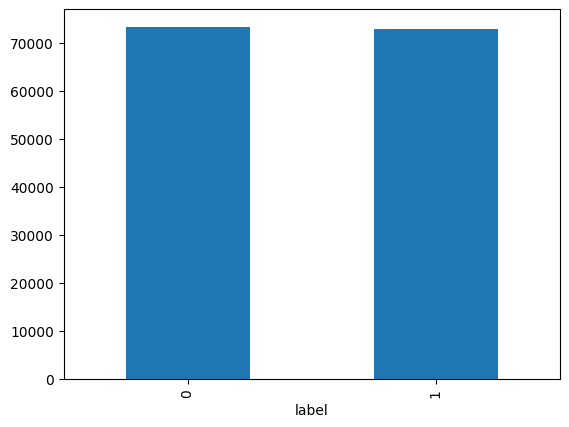

In [ ]:
# train_data['label'].value_counts().plot(kind = 'bar')

In [6]:
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

path = '/content/drive/MyDrive/'
df = pd.read_pickle(path+'movie_reviews_20240419.pkl')
# df.head(2)

# 'review_body'와 'star_rating' columns로 새로운 데이터 프레임 생성하기
new_df = df[['clean_review', '별점']]

# 긍정/부정 이진 분류를 위해 평점 1-6까지는 0으로 변환, 7-10는 1로 변환
# 긍정 1 부정 0
new_df["별점"] = new_df["별점"].astype(int)
new_df["별점"] = np.where(new_df["별점"] <= 6, 0, 1)

new_df.columns = ['document', 'label']
new_df

<ipython-input-6-ef45c508af75>:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["별점"] = new_df["별점"].astype(int)
<ipython-input-6-ef45c508af75>:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df["별점"] = np.where(new_df["별점"] <= 6, 0, 1)


,document,label
0,기대를 져버리지 않는 송민경,1
1,연출이랑 편집이 급하게 처리한 느낌이 들어 아쉬웠습니다 배우들은 다들 앞으로의 ...,1
2,송민경 폼 미쳤다 굉장하다 송배우,1
3,주연 배우님들 연기대박 다음 작품이 또 기대 되네요재미있게 봤어요,1
4,송민경 이쁨 알콩달콩 하는게 제법 귀엽,1
...,...,...
68872,괜찮았어요 볼만했습니다,1
68873,연출로 감출수 없는 예산의 한계,0
68874,그냥 그럭저럭 나쁘지 않음,0
68875,최면술사가 프로페서 X는 아니잖아 연기들은 다 좋음,0


In [7]:
# Train , Test dataset split을 위한 변수 설정 (Train = 0.8 : Test = 0.2)
num_ex = new_df.shape[0]
slicing = int(0.8*num_ex)
print(slicing)

# Train dataset & Test dataset 분리
train_df = new_df.iloc[:slicing, :]
test_df = new_df.iloc[slicing:, :]

# test_df.reset_index()

print(f"Train dataset's shape : {train_df.shape}")
print(f"Test dataset's shape : {test_df.shape}")

55101
Train dataset's shape : (55101, 2)
Test dataset's shape : (13776, 2)


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55101 entries, 0 to 55100
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   document  55101 non-null  object
 1   label     55101 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 861.1+ KB


In [ ]:
# train_a = pd.concat([train_data, train_df])

In [ ]:
# print(train_a.groupby('label').size().reset_index(name = 'count'))

   label   count
0      0   86172
1      1  115112


In [ ]:
# test_a = pd.concat([test_data, test_df])

In [12]:
# Train , Test dataset split을 위한 변수 설정 (Train = 0.8 : Test = 0.2)
# num_ex = new_df.shape[0]
# slicing = int(0.8*num_ex)
# print(slicing)

# Train dataset & Test dataset 분리
# train_df = new_df.iloc[:slicing, :]
# test_df = new_df.iloc[slicing:, :]

# test_df.reset_index()

# train_df = train_a.copy()
# test_df = test_a.copy()

print(f"Train dataset's shape : {train_df.shape}")
print(f"Test dataset's shape : {test_df.shape}")

Train dataset's shape : (55101, 2)
Test dataset's shape : (13776, 2)


In [13]:
print(train_df.isnull().sum())
print(test_df.isnull().sum())

document    0
label       0
dtype: int64
document    0
label       0
dtype: int64


In [14]:
train_df.loc[train_df.document.isnull()]

,document,label


In [ ]:
train_df = train_df.dropna(how = 'any')
test_df = test_df.dropna(how = 'any')

In [8]:
## 텍스트 데이터 전처리
#알파벳과 공백을 제외하고 모두 제거
eng_text = 'do!!! you expect... people~ to~ read~ the FAQ, etc. and actually accept hard~! atheism?@@'
print(re.sub(r'[^a-zA-Z ]', '', eng_text))

# 한글과 공백을 제외하고 모두 제거
train_df['document'] = train_df['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","")
train_df[:5]

do you expect people to read the FAQ etc and actually accept hard atheism


<ipython-input-8-ba7b97288af7>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['document'] = train_df['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","")


,document,label
0,기대를 져버리지 않는 송민경,1
1,연출이랑 편집이 급하게 처리한 느낌이 들어 아쉬웠습니다 배우들은 다들 앞으로의 ...,1
2,송민경 폼 미쳤다 굉장하다 송배우,1
3,주연 배우님들 연기대박 다음 작품이 또 기대 되네요재미있게 봤어요,1
4,송민경 이쁨 알콩달콩 하는게 제법 귀엽,1


In [9]:
train_df['document'] = train_df['document'].str.replace('^ +', "") # white space 데이터를 empty value로 변경
train_df['document'].replace('', np.nan, inplace=True)
print(train_df.isnull().sum())

document    46
label        0
dtype: int64


<ipython-input-9-298093a3daef>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['document'] = train_df['document'].str.replace('^ +', "") # white space 데이터를 empty value로 변경
<ipython-input-9-298093a3daef>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df['document'].replace('', np.nan, inplace=True)


In [10]:
test_df.drop_duplicates(subset = ['document'], inplace=True) # document 열에서 중복인 내용이 있다면 중복 제거
test_df['document'] = test_df['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","") # 정규 표현식 수행
test_df['document'] = test_df['document'].str.replace('^ +', "") # 공백은 empty 값으로 변경
test_df['document'].replace('', np.nan, inplace=True) # 공백은 Null 값으로 변경
test_df = test_df.dropna(how='any') # Null 값 제거
print('전처리 후 테스트용 샘플의 개수 :',len(test_df))

전처리 후 테스트용 샘플의 개수 : 13023


<ipython-input-10-02e3bfe3d63c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df.drop_duplicates(subset = ['document'], inplace=True) # document 열에서 중복인 내용이 있다면 중복 제거
<ipython-input-10-02e3bfe3d63c>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_df['document'] = test_df['document'].str.replace("[^ㄱ-ㅎㅏ-ㅣ가-힣 ]","") # 정규 표현식 수행
<ipython-input-10-02e3bfe3d63c>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

## 형태소 분석
- 불용어처리
- Okt(Open Korea Text)


In [11]:
## 불용어 정의
!wget https://raw.githubusercontent.com/byungjooyoo/Dataset/main/korean_stopwords.txt
with open('korean_stopwords.txt', 'r') as f:
    stop_words = f.read().split("\n")
print(len(stop_words), stop_words[:10])
stopwords = ['는', '두', '의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다', ''] + stop_words
print(len(stop_words), stop_words[:10])

## 형태소 분석기
okt = Okt()
okt.morphs('와 이런 것도 영화라고 차라리 뮤직비디오를 만드는 게 나을 뻔', stem = True)

--2024-04-24 18:13:28--  https://raw.githubusercontent.com/byungjooyoo/Dataset/main/korean_stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7007 (6.8K) [text/plain]
Saving to: ‘korean_stopwords.txt’

korean_stopwords.tx 100%[===================>]   6.84K  --.-KB/s    in 0s      

2024-04-24 18:13:28 (58.3 MB/s) - ‘korean_stopwords.txt’ saved [7007/7007]

675 ['아', '휴', '아이구', '아이쿠', '아이고', '어', '나', '우리', '저희', '따라']
675 ['아', '휴', '아이구', '아이쿠', '아이고', '어', '나', '우리', '저희', '따라']


['오다', '이렇다', '것', '도', '영화', '라고', '차라리', '뮤직비디오', '를', '만들다', '게', '나다', '뻔']

In [12]:
X_train = []
for sentence in tqdm(train_df['document']):
    tokenized_sentence = okt.morphs(str(sentence), stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    X_train.append(stopwords_removed_sentence)

print(X_train[:3])

100%|██████████| 55101/55101 [04:17<00:00, 214.07it/s]

[['기대', '지다', '버리다', '않다', '송민경'], ['연출', '이랑', '편집', '급하다', '처리', '느낌', '들다', '아쉽다', '배우', '다', '들다', '앞', '으로의', '연기', '기대', '되다', '가능성', '보이다', '편집', '이랑', '음향', '만', '재', '편집', '개봉', '더', '주목', '받다', '영화', '이다'], ['송민경', '폼', '미치다', '굉장하다', '송', '배우']]


In [13]:
X_test = []
for sentence in tqdm(test_df['document']):
    tokenized_sentence = okt.morphs(sentence, stem=True) # 토큰화
    stopwords_removed_sentence = [word for word in tokenized_sentence if not word in stopwords] # 불용어 제거
    X_test.append(stopwords_removed_sentence)

100%|██████████| 13023/13023 [00:58<00:00, 224.50it/s]


In [14]:
## 토크나이저
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)

In [15]:
print(tokenizer.word_index)

{'보다': 1, '영화': 2, '좋다': 3, '재밌다': 4, '이다': 5, '너무': 6, '자다': 7, '되다': 8, '연기': 9, '적': 10, '없다': 11, '않다': 12, '만': 13, '배우': 14, '생각': 15, '수': 16, '재미있다': 17, '더': 18, '다': 19, '스토리': 20, '볼': 21, '아니다': 22, '감동': 23, '나오다': 24, '인': 25, '가다': 26, '아쉽다': 27, '정말': 28, '연출': 29, '보고': 30, '게': 31, '진짜': 32, '안': 33, '만들다': 34, '고': 35, '사람': 36, '최고': 37, '싶다': 38, '이야기': 39, '들다': 40, '액션': 41, '하고': 42, '못': 43, '느낌': 44, '그냥': 45, '많다': 46, '모르다': 47, '감독': 48, '기대': 49, '요': 50, '1': 51, '보기': 52, '그렇다': 53, '관람': 54, '작품': 55, '오다': 56, '내': 57, '사랑': 58, '많이': 59, '장면': 60, '알다': 61, '재미': 62, '다시': 63, '님': 64, '2': 65, '마지막': 66, '중': 67, '이렇다': 68, '말': 69, '좋아하다': 70, '영상': 71, '내용': 72, '느끼다': 73, '꼭': 74, '추천': 75, '노래': 76, '없이': 77, '지루하다': 78, '편': 79, '정도': 80, '귀엽다': 81, '크다': 82, '되어다': 83, '괜찮다': 84, '3': 85, '캐릭터': 86, '듯': 87, '역시': 88, '거': 89, '마음': 90, '몰입': 91, '알': 92, '음악': 93, '극장': 94, '나다': 95, '시리즈': 96, '영화관': 97, 'ost': 98, '모든': 99, '부분': 100, '상미': 

In [16]:
## 등장 빈도수가 3회 미만인 단어들이 이 데이터에서 얼만큼의 비중을 차지하는지 확인
threshold = 3
total_cnt = len(tokenizer.word_index) # 단어의 수
rare_cnt = 0 # 등장 빈도수가 threshold보다 작은 단어의 개수를 카운트
total_freq = 0 # 훈련 데이터의 전체 단어 빈도수 총 합
rare_freq = 0 # 등장 빈도수가 threshold보다 작은 단어의 등장 빈도수의 총 합

# 단어와 빈도수의 쌍(pair)을 key와 value로 받는다.
for key, value in tokenizer.word_counts.items():
    total_freq = total_freq + value

    # 단어의 등장 빈도수가 threshold보다 작으면
    if(value < threshold):
        rare_cnt = rare_cnt + 1
        rare_freq = rare_freq + value

print('단어 집합(vocabulary)의 크기 :',total_cnt)
print('등장 빈도가 %s번 이하인 희귀 단어의 수: %s'%(threshold - 1, rare_cnt))
print("단어 집합에서 희귀 단어의 비율:", (rare_cnt / total_cnt)*100)
print("전체 등장 빈도에서 희귀 단어 등장 빈도 비율:", (rare_freq / total_freq)*100)

단어 집합(vocabulary)의 크기 : 21153
등장 빈도가 2번 이하인 희귀 단어의 수: 11378
단어 집합에서 희귀 단어의 비율: 53.78906065333522
전체 등장 빈도에서 희귀 단어 등장 빈도 비율: 2.550883603199062


In [17]:
# 전체 단어 개수 중 빈도수 2이하인 단어는 제거.
# 0번 패딩 토큰을 고려하여 + 1
vocab_size = total_cnt - rare_cnt + 1
print('단어 집합의 크기 :',vocab_size)

단어 집합의 크기 : 9776


In [18]:
# 텍스트 시퀀스를 정수 시퀀스로 변환
tokenizer = Tokenizer(vocab_size)
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

print(X_train[:3])

[[49, 379, 186, 12, 8157], [29, 230, 533, 2067, 3595, 44, 40, 27, 14, 19, 40, 251, 2303, 9, 49, 8, 1894, 187, 533, 230, 1034, 13, 274, 533, 129, 18, 3596, 108, 2, 5], [8157, 1728, 114, 506, 6389, 14]]


In [19]:
# 학습을 위한 정답 데이터(Y) 만들기
train_Y = np.array(train_df['label'])
test_Y = np.array(test_df['label'])

print(f"train_Y shape : {train_Y.shape}")
print(f"test_Y shape : {test_Y.shape}")

train_Y shape : (55101,)
test_Y shape : (13023,)


In [20]:
#  Dataframe의 review_body 부분을 list로 변환
# trian_df , test_df에서 각각 review body 부분을 리스트로 변환
train_text_X = train_df['document'].values.tolist()
test_text_X = test_df['document'].values.tolist()

print(len(train_text_X))
print(type(train_text_X))

print(train_text_X[0])
print(test_text_X[0])

55101
<class 'list'>
기대를 져버리지 않는 송민경
생각보다 유쾌했던         


In [21]:
# 띄어쓰기 단위로 단어 분리

# 문장을 띄어쓰기 단위로 단어 분리 (Train data)
train_sentences = [str(sentence).split(' ') for sentence in train_text_X]
for i in range(5):
    print(train_sentences[i])

print("\n")

# 문장을 띄어쓰기 단위로 단어 분리 (Train data)
test_sentences = [sentence.split(' ') for sentence in test_text_X]
for i in range(5):
    print(test_sentences[i])

['기대를', '져버리지', '않는', '송민경']
['연출이랑', '편집이', '급하게', '처리한', '느낌이', '들어', '아쉬웠습니다', '', '', '배우들은', '다들', '앞으로의', '연기가', '기대될만큼', '가능성이', '보였습니다', '', '', '편집이랑', '음향만', '재편집해서', '개봉하면', '더', '주목받을만한', '영화였어요', '']
['송민경', '폼', '미쳤다', '굉장하다', '송배우']
['주연', '배우님들', '연기대박', '', '다음', '작품이', '또', '기대', '되네요재미있게', '봤어요', '', '', '', '', '', '', '']
['송민경', '이쁨', '', '', '알콩달콩', '하는게', '제법', '귀엽']


['생각보다', '유쾌했던', '', '', '', '', '', '', '', '', '']
['정글번치도', '시리즈', '영화관', '애니메이션이었군요', '', '', '전작도', '찾아', '보고', '싶은', '마음이에요', '']
['영화보는', '극장', '안에서', '주변', '아이들이', '좋아했던', '영화']
['캐릭터들이', '재밌네여', '잘봤습니다']
['영화', '정글번치', '월드투어', '잘', '봤습니다']


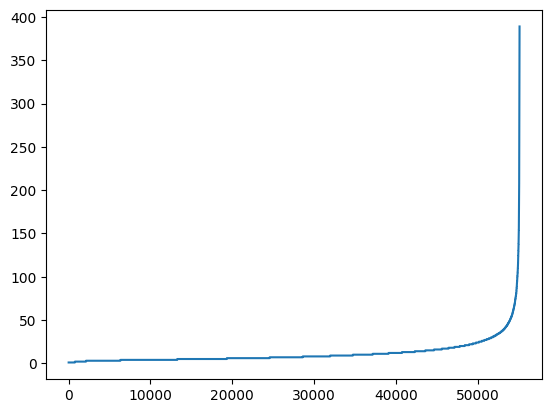

51828


In [22]:
# 문장별 단어 수를 체크
# 각 문장의 단어 길이 확인 (Train)

import matplotlib.pyplot as plt
sentence_len = [len(sentence) for sentence in train_sentences]
sentence_len.sort()
plt.plot(sentence_len)
plt.show()

print(sum([int(l<=30) for l in sentence_len]))
# 55101 51828
# 전체 문장의 94% 가량이 30개 이하의 단어를 사용

In [23]:
# 단어 정제 및 문장 길이 줄임 (Train)
sentences_new = []
for sentence in train_sentences:
# 각 문장의 단어 개수를 30개 까지의 제한하고 각 단어를 10글자로 제한
    sentences_new.append([word[:100] for word in sentence if word != ''][:30])
train_sentences = sentences_new
for i in range(5):
    print(train_sentences[i])

['기대를', '져버리지', '않는', '송민경']
['연출이랑', '편집이', '급하게', '처리한', '느낌이', '들어', '아쉬웠습니다', '배우들은', '다들', '앞으로의', '연기가', '기대될만큼', '가능성이', '보였습니다', '편집이랑', '음향만', '재편집해서', '개봉하면', '더', '주목받을만한', '영화였어요']
['송민경', '폼', '미쳤다', '굉장하다', '송배우']
['주연', '배우님들', '연기대박', '다음', '작품이', '또', '기대', '되네요재미있게', '봤어요']
['송민경', '이쁨', '알콩달콩', '하는게', '제법', '귀엽']


In [24]:
# Test 데이터에도 동일하게 적용

# 단어 정제 및 문장 길이 줄임 (Test)
sentences_new = []
for sentence in test_sentences:
    sentences_new.append([word[:100] for word in sentence if word != ''][:30])
sentences = sentences_new

In [26]:
##  Tokenizer와 pad_seequences를 사용해 문장 전처리
# Tokenizer는 데이터에 출현하는 모든 단어의 개수를 세고 빈도수로 정렬을 해줍니다.
# 이 때, num_words에 지정된 만큼만 숫자로 반환하고, 나머지는 0으로 반환합니다.

# fit_on_texts 메서드를 통해 원하는 text datasets를 처리 가능하며,
# texts_to_sequences 메서드로 각 단어는 index(number)로 변환됩니다.

# pad_sequences는 단어가 없는 반 부분에 padding을 넣는 역할을 합니다.

# Tokenizer와 pad_sequences를 사용한 문장 전처리 (Train)

# tokenizer setting
tokenizer = Tokenizer(num_words=8000)  # 단어 빈도수가 높은 8000개만 사용

# train_sentences를 tokenizer에 대입
tokenizer.fit_on_texts(train_sentences)

# tokenizer에 의해 구해진 단어의 index로 train_X 생성
train_X = tokenizer.texts_to_sequences(train_sentences)

# 단어가 없는 부분이나 tokenizer num_words에 속하지 못한 단어 부분에 패딩을 넣음
train_X = pad_sequences(train_X, padding='post')

print(train_X[:5])

[[ 267  182    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]
 [3300 2276 3004  184 2862  850 1871  242 3704   29 7204 5877    7  187
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]
 [2173  450    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]
 [ 890 1209  258  777   45   93   23    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]
 [4864 2863 4540 4865    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0]]


In [27]:
# Text 데이터도 동일하게 처리
# Tokenizer와 pad_sequences를 사용한 문장 전처리 (Test)

# train_sentences로 fit된 tokenizer 사용
test_X = tokenizer.texts_to_sequences(sentences)
test_X = pad_sequences(test_X, padding='post')

In [28]:
# Tokenizer의 동작 확인
print(tokenizer.index_word[629])
print(tokenizer.index_word[758])
temp = tokenizer.texts_to_sequences(['사이몬페그의', '연출로', '난해하고', '했던'])
print(temp)
temp = pad_sequences(temp, padding='post')
print(temp)

절대
톰
[[], [1805], [2148], [809]]
[[   0]
 [1805]
 [2148]
 [ 809]]


In [ ]:
print('리뷰의 최대 길이 :',max( len(str(document)) for document in list(train_df['document']) ) )
print('리뷰의 평균 길이 :',sum(map(len, list(train_df['document'].str)))/len(list(train_df['document'])))
plt.hist([len(document) for document in train_df], bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.show()

## 모델학습 및 평가

#### GRU로 감성분석

In [37]:
from tensorflow.keras.layers import Embedding, Dense, GRU
from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

embedding_dim = 100
hidden_units = 128

model = Sequential()
model.add(Embedding(vocab_size, embedding_dim))
model.add(GRU(hidden_units))
model.add(Dense(1, activation='sigmoid'))

es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('best_model.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(train_X, train_Y, epochs=15, callbacks=[es, mc], batch_size=64, validation_split=0.2)

Epoch 1/15
689/689 [==============================] - ETA: 0s - loss: 0.5459 - acc: 0.7666
Epoch 1: val_acc improved from -inf to 0.76953, saving model to best_model.h5
689/689 [==============================] - 59s 82ms/step - loss: 0.5459 - acc: 0.7666 - val_loss: 0.5414 - val_acc: 0.7695
Epoch 2/15
  1/689 [..............................] - ETA: 1:08 - loss: 0.5456 - acc: 0.7656

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


689/689 [==============================] - ETA: 0s - loss: 0.5445 - acc: 0.7666
Epoch 2: val_acc did not improve from 0.76953
689/689 [==============================] - 56s 82ms/step - loss: 0.5445 - acc: 0.7666 - val_loss: 0.5434 - val_acc: 0.7695
Epoch 3/15
689/689 [==============================] - ETA: 0s - loss: 0.5444 - acc: 0.7666
Epoch 3: val_acc did not improve from 0.76953
689/689 [==============================] - 57s 82ms/step - loss: 0.5444 - acc: 0.7666 - val_loss: 0.5399 - val_acc: 0.7695
Epoch 4/15
689/689 [==============================] - ETA: 0s - loss: 0.5440 - acc: 0.7666
Epoch 4: val_acc did not improve from 0.76953
689/689 [==============================] - 57s 82ms/step - loss: 0.5440 - acc: 0.7666 - val_loss: 0.5401 - val_acc: 0.7695
Epoch 5/15
689/689 [==============================] - ETA: 0s - loss: 0.5442 - acc: 0.7666
Epoch 5: val_acc did not improve from 0.76953
689/689 [==============================] - 62s 90ms/step - loss: 0.5442 - acc: 0.7666 - val_lo

In [66]:
loaded_model = load_model('best_model.h5')
print("\n 테스트 정확도: %.4f" % (loaded_model.evaluate(test_X, test_Y)[1]))

407/407 [==============================] - 6s 12ms/step - loss: 0.4547 - acc: 0.7976

 테스트 정확도: 0.7976


##### 리뷰예측

In [43]:
## 리뷰예측
def sentiment_predict(new_sentence):
  new_sentence = re.sub(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]','', new_sentence)
  new_sentence = okt.morphs(new_sentence)
  new_sentence = [word for word in new_sentence if not word in stopwords]
  encoded = tokenizer.texts_to_sequences([new_sentence])
  pad_new = pad_sequences(encoded, maxlen = 80)

  score = float(loaded_model.predict(pad_new))
  if(score > 0.5):
    print("{:.2f}% 확률로 긍정 리뷰입니다.".format(score * 100))
  else:
    print("{:.2f}% 확률로 부정 리뷰입니다.".format((1 - score) * 100))

In [44]:
sentiment_predict('이 시리즈는 이제 대한민국 영화의 전설이 되었다. 벌써 다음편들이 기다려진다.')

1/1 [==============================] - 1s 967ms/step
89.80% 확률로 부정 리뷰입니다.


<ipython-input-43-201786eb49a0>:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


In [45]:
sentiment_predict('볼필요없다. 재미없음.')

1/1 [==============================] - 0s 25ms/step
56.21% 확률로 부정 리뷰입니다.


<ipython-input-43-201786eb49a0>:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  score = float(loaded_model.predict(pad_new))


### LSTM 사용

In [46]:
##  Model 정의 및 학습
# Embedding 레이어와 LSTM 레이어 Dense 레이어를 차례대로 쌓아줍니다.

# Embedding 레이어에서 30000은 tokenizer 선언 시 결정한 num_words의 수이고,
# 400은 해당 30000개의 단어를 몇차원의 벡터로 변환할 지 결정하는 인자입니다.
# 즉, 30000개의 단어를 400차원의 벡터로 임베딩을 하겠다는 말입니다.
# input_length는 Embedding 레이어에 입력의 크기(차원)이며, 앞서 15개의 단어로 자른 것을 의미합니다.

# LSTM 레이어에서 units은 은닉 값 또는 출력 값(Hidden State value)의 차원을 정하는 인자입니다.

# 긍정/부정 이진 분류를 위한 모델임으로 Dense 레이어의 출력은 2가 됩니다.

# LSTM 레이어를 사용한 모델 정의
model2 = tf.keras.Sequential([
    tf.keras.layers.Embedding(8000, 100, input_length=30),
    tf.keras.layers.LSTM(units=50),
    tf.keras.layers.Dense(2, activation='softmax')
])

model2.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['acc'])
model2.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 30, 100)           800000    
                                                                 
 lstm (LSTM)                 (None, 50)                30200     
                                                                 
 dense_1 (Dense)             (None, 2)                 102       
                                                                 
Total params: 830302 (3.17 MB)
Trainable params: 830302 (3.17 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [47]:
es = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('best_model_lstm.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

# 모델 학습
history = model2.fit(train_X, train_Y, epochs=5, callbacks=[es, mc], batch_size=128, validation_split=0.2)

Epoch 1/5
345/345 [==============================] - 26s 65ms/step - loss: 0.5049 - accuracy: 0.7762 - val_loss: 0.4320 - val_accuracy: 0.8023
Epoch 2/5
345/345 [==============================] - 25s 72ms/step - loss: 0.3937 - accuracy: 0.8257 - val_loss: 0.4423 - val_accuracy: 0.8014
Epoch 3/5
345/345 [==============================] - 26s 76ms/step - loss: 0.3530 - accuracy: 0.8437 - val_loss: 0.4553 - val_accuracy: 0.7972
Epoch 4/5
345/345 [==============================] - 32s 92ms/step - loss: 0.3218 - accuracy: 0.8563 - val_loss: 0.4601 - val_accuracy: 0.7951
Epoch 5/5
345/345 [==============================] - 27s 78ms/step - loss: 0.2906 - accuracy: 0.8670 - val_loss: 0.5359 - val_accuracy: 0.7917


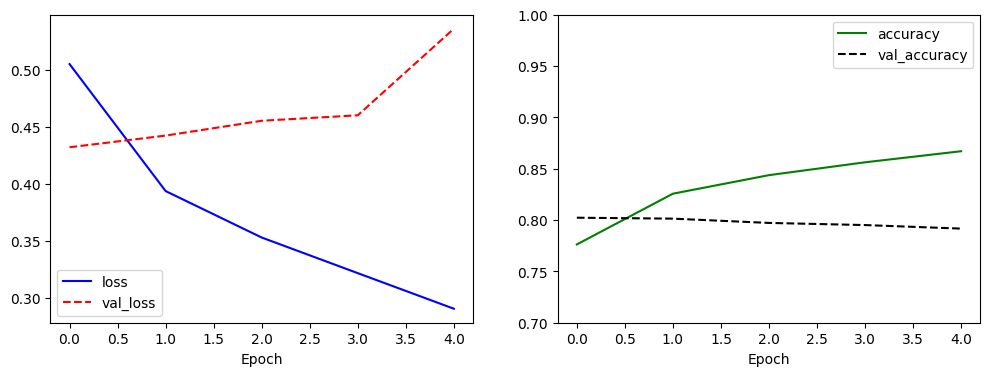

In [48]:
# 모델 학습 결과 확인
def show_plt(history):
  plt.figure(figsize=(12, 4))

  plt.subplot(1, 2, 1)
  plt.plot(history.history['loss'], 'b-', label='loss')
  plt.plot(history.history['val_loss'], 'r--', label='val_loss')
  plt.xlabel('Epoch')
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(hist.history['accuracy'], 'g-', label='accuracy')
  plt.plot(hist.history['val_accuracy'], 'k--', label='val_accuracy')
  plt.xlabel('Epoch')
  plt.ylim(0.7, 1)
  plt.legend()

  plt.show()

show_plt(history)

In [50]:
# 모델링 다른코드
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM

max_words = 8000

model3 = Sequential()
model3.add(Embedding(max_words, 64))
model3.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2))
model3.add(Dense(1, activation='sigmoid'))
model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

# 모델 학습
hes = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('best_model_lstm2.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

hist = model3.fit(train_X, train_Y, batch_size=32, epochs=5, callbacks=[es, mc], validation_split=0.2)

loss, acc = model3.evaluate(test_X, test_Y, batch_size=32)

print('Test loss:', loss)
print('Test accuracy:', acc)

Epoch 1/5
1378/1378 [==============================] - ETA: 0s - loss: 0.4725 - accuracy: 0.7860

1378/1378 [==============================] - 91s 62ms/step - loss: 0.4725 - accuracy: 0.7860 - val_loss: 0.4347 - val_accuracy: 0.8020
Epoch 2/5
1378/1378 [==============================] - ETA: 0s - loss: 0.3850 - accuracy: 0.8297

1378/1378 [==============================] - 92s 66ms/step - loss: 0.3850 - accuracy: 0.8297 - val_loss: 0.4333 - val_accuracy: 0.8012
Epoch 3/5
1377/1378 [============================>.] - ETA: 0s - loss: 0.3503 - accuracy: 0.8455

1378/1378 [==============================] - 82s 59ms/step - loss: 0.3503 - accuracy: 0.8455 - val_loss: 0.4530 - val_accuracy: 0.8002
Epoch 4/5
1377/1378 [============================>.] - ETA: 0s - loss: 0.3240 - accuracy: 0.8565

1378/1378 [==============================] - 82s 59ms/step - loss: 0.3240 - accuracy: 0.8565 - val_loss: 0.4781 - val_accuracy: 0.7970
Epoch 5/5
1378/1378 [==============================] - ETA: 0s - loss: 0.2989 - accuracy: 0.8665

407/407 [==============================] - 4s 9ms/step - loss: 0.5581 - accuracy: 0.7836
Test loss: 0.5580790638923645
Test accuracy: 0.7836136221885681


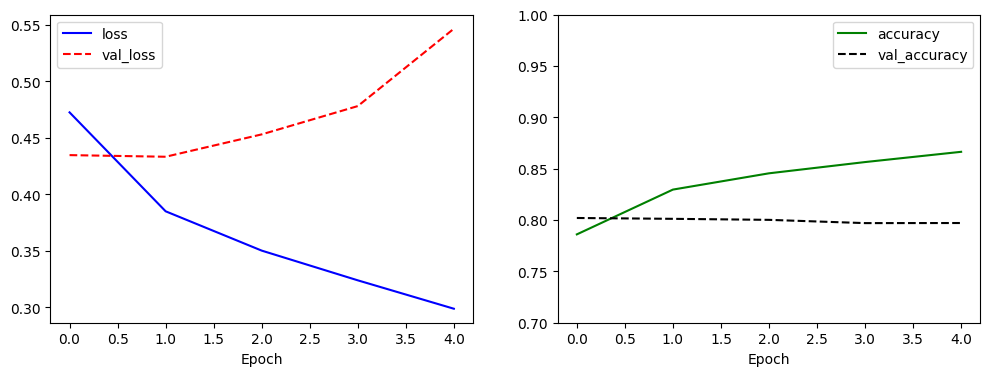

In [78]:
show_plt(hist)

In [55]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dense


# 리뷰를 정수 시퀀스로 변환
vocab_size = 8000  # 사용할 단어의 최대 개수
max_len = 30  # 리뷰의 최대 길이
# tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=vocab_size)
# tokenizer.fit_on_texts(reviews)
# sequences = tokenizer.texts_to_sequences(reviews)
# X_data = pad_sequences(sequences, maxlen=max_len)

# LSTM 모델 구축
model4 = Sequential()
model4.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=max_len))
model4.add(LSTM(units=32, dropout=0.2, recurrent_dropout=0.2 ))
model4.add(Dense(units=1, activation='sigmoid'))

# 모델 컴파일
model4.compile(optimizer='adam', loss='binary_crossentropy', metrics=['acc'])

# 모델 학습
hes = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=4)
mc = ModelCheckpoint('best_model_lstm3.h5', monitor='val_acc', mode='max', verbose=1, save_best_only=True)

history = model4.fit(train_X, train_Y, epochs=5, callbacks=[es, mc], batch_size=128, validation_split=0.2)

Epoch 1/5
345/345 [==============================] - ETA: 0s - loss: 0.5286 - acc: 0.7675
Epoch 1: val_acc improved from -inf to 0.79875, saving model to best_model_lstm3.h5
345/345 [==============================] - 30s 73ms/step - loss: 0.5286 - acc: 0.7675 - val_loss: 0.4468 - val_acc: 0.7987
Epoch 2/5
  1/345 [..............................] - ETA: 32s - loss: 0.3857 - acc: 0.8281

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


344/345 [============================>.] - ETA: 0s - loss: 0.4049 - acc: 0.8226
Epoch 2: val_acc improved from 0.79875 to 0.80401, saving model to best_model_lstm3.h5
345/345 [==============================] - 24s 71ms/step - loss: 0.4049 - acc: 0.8225 - val_loss: 0.4292 - val_acc: 0.8040
Epoch 3/5
344/345 [============================>.] - ETA: 0s - loss: 0.3640 - acc: 0.8413
Epoch 3: val_acc did not improve from 0.80401
345/345 [==============================] - 28s 81ms/step - loss: 0.3640 - acc: 0.8414 - val_loss: 0.4330 - val_acc: 0.8012
Epoch 4/5
344/345 [============================>.] - ETA: 0s - loss: 0.3381 - acc: 0.8512
Epoch 4: val_acc did not improve from 0.80401
345/345 [==============================] - 25s 72ms/step - loss: 0.3382 - acc: 0.8512 - val_loss: 0.4592 - val_acc: 0.7907
Epoch 5/5
345/345 [==============================] - ETA: 0s - loss: 0.3154 - acc: 0.8590
Epoch 5: val_acc did not improve from 0.80401
345/345 [==============================] - 26s 76ms/step

In [60]:
# 평가
model2.evaluate(test_X, test_Y, verbose=2)

407/407 - 3s - loss: 0.5321 - accuracy: 0.7832 - 3s/epoch - 9ms/step


[0.5320596694946289, 0.7831528782844543]

In [59]:
# 평가
model3.evaluate(test_X, test_Y, verbose=2)

407/407 - 3s - loss: 0.5581 - accuracy: 0.7836 - 3s/epoch - 7ms/step


[0.5580790638923645, 0.7836136221885681]

In [61]:
# 평가
model4.evaluate(test_X, test_Y, verbose=2)

407/407 - 3s - loss: 0.5092 - acc: 0.7771 - 3s/epoch - 6ms/step


[0.5091699957847595, 0.7770866751670837]

In [75]:
## 임의로 만든 문장으로 모델 성능을 확인
test_sentence = '왜 이렇게 평이 좋은지 모르겠음.'
test_sentence = test_sentence.split(' ')
test_sentences = []
now_sentence = []
for word in test_sentence:
    now_sentence.append(word)
    test_sentences.append(now_sentence[:])

test_X_1 = tokenizer.texts_to_sequences(test_sentences)
test_X_1 = pad_sequences(test_X_1, padding='post', maxlen=30)
prediction = model.predict(test_X_1)
for idx, sentence in enumerate(test_sentences):
    print(sentence)
    print(prediction[idx])

# 0.5 아래로 부정, 이상이면 긍정

1/1 [==============================] - 0s 111ms/step
['왜']
[0.62499064]
['왜', '이렇게']
[0.62499064]
['왜', '이렇게', '평이']
[0.62499064]
['왜', '이렇게', '평이', '좋은지']
[0.62499064]
['왜', '이렇게', '평이', '좋은지', '모르겠음.']
[0.62499064]


In [76]:
## 임의로 만든 문장으로 모델 성능을 확인
test_sentence = '힙노틱 기대되는 영화입니다 재밌어요'
test_sentence = test_sentence.split(' ')
test_sentences = []
now_sentence = []
for word in test_sentence:
    now_sentence.append(word)
    test_sentences.append(now_sentence[:])

test_X_1 = tokenizer.texts_to_sequences(test_sentences)
test_X_1 = pad_sequences(test_X_1, padding='post', maxlen=30)
prediction = model.predict(test_X_1)
for idx, sentence in enumerate(test_sentences):
    print(sentence)
    print(prediction[idx])

# 0.5 아래로 부정, 이상이면 긍정

1/1 [==============================] - 0s 27ms/step
['힙노틱']
[0.62499064]
['힙노틱', '기대되는']
[0.62499064]
['힙노틱', '기대되는', '영화입니다']
[0.62499064]
['힙노틱', '기대되는', '영화입니다', '재밌어요']
[0.62499064]
